# Clustering non supervisionato (type)

In [16]:
import pandas as pd

df = pd.read_csv("/Users/deniseatzori/Library/Mobile Documents/com~apple~CloudDocs/ENC-PSL/Memoire/Github_tesi/tf-idf_personnages_ann.csv")

In [17]:
# creation d'un nouveau dataframe ne contenant que les types 0 (adult) et 1 (enfant)
df = df[df["type"].isin([0,1])]

In [18]:
# suppression de la colonne des titres et des celles du genre
df.drop(columns=["title", "Gender","author_gender"], axis=1, inplace=True)

In [19]:
df.head(5)

,type,text
0,1.0,remplir humer répondre avoir ajouter souffrir ...
1,0.0,manger entrer penser trouver passer dire prête...
2,1.0,venir ébrouer obéir acheter rire garder ajoute...
3,0.0,devenir connaître tirer ouvrir donner reprendr...
4,1.0,arriver répondre entendre répondre écouter saî...


In [20]:
documents = df["text"].tolist()
y = df["type"].tolist()

## Creazione matrice TF-IDF

Dato che lavoro su personaggi, potrebbe essere utile:

min_df=2 o 3
max_df=0.8

Perché:

- elimina parole che compaiono in un solo personaggio
- elimina parole troppo comuni (tipo "faire", "dire", "être")

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(min_df=2)
X_tfidf = vectorizer.fit_transform(documents)

## Riduzione di dimensioni con UMAP

In [22]:
import umap

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=2,   # 2D per visualizzazione
    metric='cosine',  # molto importante per TF-IDF
    random_state=42
)

X_umap = umap_model.fit_transform(X_tfidf)

/Users/deniseatzori/miniconda3/envs/Tesi/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Clustering con HDBSCAN

HDBSCAN - Hierarchical Density-Based Spatial Clustering of Applications with Noise. Performs DBSCAN over varying epsilon values and integrates the result to find a clustering that gives the best stability over epsilon. This allows HDBSCAN to find clusters of varying densities (unlike DBSCAN), and be more robust to parameter selection. Read more in the User Guide: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.HDBSCAN.html

In [23]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=5)
labels = clusterer.fit_predict(X_umap)

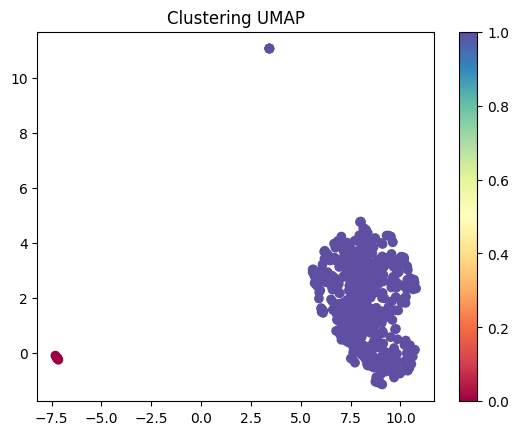

In [24]:
import matplotlib.pyplot as plt

plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='Spectral')
plt.colorbar()
plt.title("Clustering UMAP")
plt.show()